In [1]:
import os
import json
from zipfile import ZipFile
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [2]:
!pip install kaggle

In [3]:
kaggle_credentails = json.load(open("kaggle-2.json"))

In [4]:
os.environ['KAGGLE_USERNAME'] = kaggle_credentails["username"]
os.environ['KAGGLE_KEY'] = kaggle_credentails["key"]

In [5]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:13<00:00, 158MB/s]



In [6]:
!ls

kaggle-2.json  plantvillage-dataset.zip  sample_data


In [7]:
with ZipFile("plantvillage-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [8]:
print(os.listdir("plantvillage dataset"))


print(len(os.listdir("plantvillage dataset/segmented")))
print(os.listdir("plantvillage dataset/segmented")[:5])

print(len(os.listdir("plantvillage dataset/color")))
print(os.listdir("plantvillage dataset/color")[:5])

print(len(os.listdir("plantvillage dataset/grayscale")))
print(os.listdir("plantvillage dataset/grayscale")[:5])

['color', 'segmented', 'grayscale']
38
['Tomato___Late_blight', 'Raspberry___healthy', 'Squash___Powdery_mildew', 'Tomato___Bacterial_spot', 'Grape___Black_rot']
38
['Tomato___Late_blight', 'Raspberry___healthy', 'Squash___Powdery_mildew', 'Tomato___Bacterial_spot', 'Grape___Black_rot']
38
['Tomato___Late_blight', 'Raspberry___healthy', 'Squash___Powdery_mildew', 'Tomato___Bacterial_spot', 'Grape___Black_rot']


In [9]:
print(len(os.listdir("plantvillage dataset/color/Grape___healthy")))
print(os.listdir("plantvillage dataset/color/Grape___healthy")[:5])


423
['bed370e7-2f48-4102-81a0-4e960d47d8c9___Mt.N.V_HL 8936.JPG', '63e38ffd-dfb4-4fc0-aee2-0e6da78a9915___Mt.N.V_HL 6028.JPG', 'b6c49725-ccb9-46a9-abca-c99f51e13d0a___Mt.N.V_HL 6026.JPG', '8f2cf5e7-ee7e-4a6e-84d2-5ac4bdb2e33f___Mt.N.V_HL 6099.JPG', '6f771370-1fb8-440e-a23f-4e0f29dbd65b___Mt.N.V_HL 6150.JPG']


In [10]:
base_dir = 'plantvillage dataset/color'

(256, 256, 3)


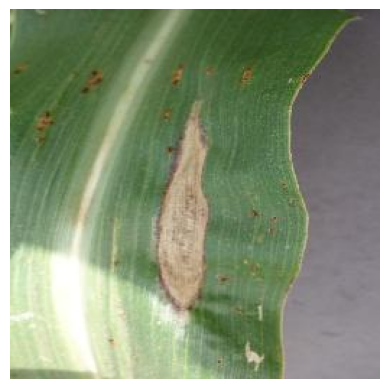

In [11]:
image_path = '/content/plantvillage dataset/color/Corn_(maize)___Northern_Leaf_Blight/00a55069-3fa3-405b-8d87-4d3408a6ed98___RS_NLB 3645.JPG'
# Read the image
img = mpimg.imread(image_path)

print(img.shape)
# Display the image
plt.imshow(img)
plt.axis('off')  # Turn off axis numbers
plt.show()

In [12]:
image_path = '/content/plantvillage dataset/color/Corn_(maize)___Northern_Leaf_Blight/00a55069-3fa3-405b-8d87-4d3408a6ed98___RS_NLB 3645.JPG'

img = mpimg.imread(image_path)

print(img)

[[[110 121  78]
  [122 135  91]
  [133 145 105]
  ...
  [ 78  73  79]
  [ 78  73  80]
  [ 78  73  80]]

 [[116 127  84]
  [126 139  95]
  [132 147 106]
  ...
  [ 78  73  79]
  [ 78  73  80]
  [ 78  73  80]]

 [[126 139  95]
  [134 147 103]
  [136 151 110]
  ...
  [ 79  74  80]
  [ 78  73  80]
  [ 78  73  80]]

 ...

 [[117 130  87]
  [112 125  82]
  [108 121  78]
  ...
  [146 141 147]
  [145 140 146]
  [145 140 146]]

 [[124 137  94]
  [119 132  89]
  [114 126  86]
  ...
  [145 140 146]
  [145 140 146]
  [145 140 146]]

 [[135 148 105]
  [130 143 100]
  [126 138  98]
  ...
  [145 140 146]
  [145 140 146]
  [145 140 146]]]


In [13]:
img_size = 224
batch_size = 32

In [14]:
data_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Use 20% of data for validation
)

In [15]:
train_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

Found 43456 images belonging to 38 classes.


In [16]:
validation_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical'
)

Found 10849 images belonging to 38 classes.


In [17]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))


model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(train_generator.num_classes, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    47,776,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,805,158 (182.36 MB)

 Trainable params: 47,805,158 (182.36 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [20]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,  # Number of steps per epoch
    epochs=5,  # Number of epochs
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size  # Validation steps
)

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 96s 65ms/step - accuracy: 0.7269 - loss: 0.9812 - val_accuracy: 0.8289 - val_loss: 0.5425
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 90s 66ms/step - accuracy: 0.9021 - loss: 0.3088 - val_accuracy: 0.8794 - val_loss: 0.4078
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 145s 69ms/step - accuracy: 0.9535 - loss: 0.1429 - val_accuracy: 0.8865 - val_loss: 0.4105
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 138s 101ms/step - accuracy: 0.9711 - loss: 0.0901 - val_accuracy: 0.8853 - val_loss: 0.4784
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 89s 66ms/step - accuracy: 0.9752 - loss: 0.0746 - val_accuracy: 0.8712 - val_loss: 0.5574


In [21]:
print("Evaluating model...")
val_loss, val_accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Evaluating model...
339/339 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.8713 - loss: 0.5559
Validation Accuracy: 87.13%


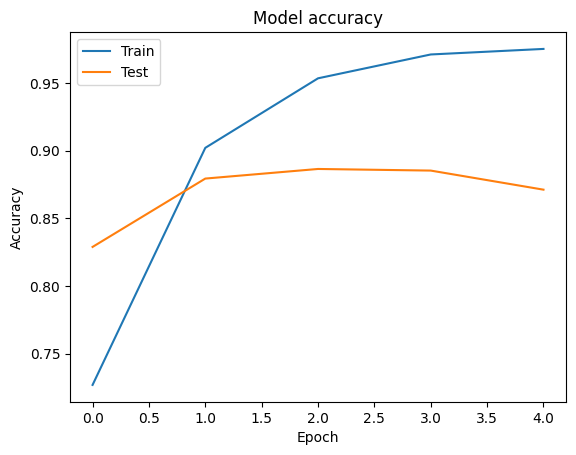

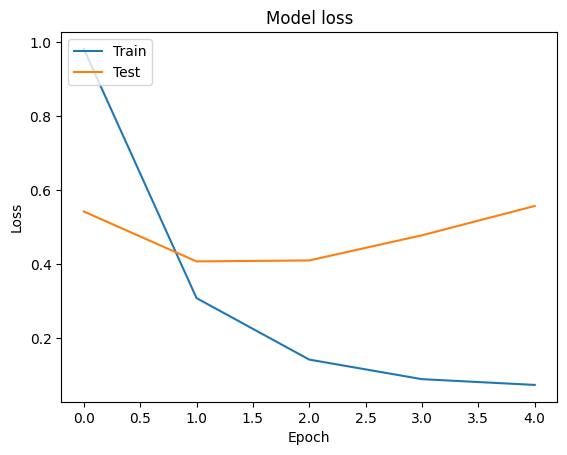

In [22]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [23]:
# Function to Load and Preprocess the Image using Pillow
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    # Load the image
    img = Image.open(image_path)
    # Resize the image
    img = img.resize(target_size)
    # Convert the image to a numpy array
    img_array = np.array(img)
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    # Scale the image values to [0, 1]
    img_array = img_array.astype('float32') / 255.
    return img_array

# Function to Predict the Class of an Image
def predict_image_class(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image(image_path)
    predictions = model.predict(preprocessed_img)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name

In [24]:
# Create a mapping from class indices to class names
class_indices = {v: k for k, v in train_generator.class_indices.items()}

In [25]:
class_indices

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [28]:
# saving the class names as json file
json.dump(class_indices, open('class_indices.json', 'w'))

In [36]:
# Example Usage
image_path = '/content/plantvillage dataset/segmented/Strawberry___healthy/01e591c9-e3e7-4edc-8211-13081f4d5e7a___RS_HL 1979_final_masked.jpg'

predicted_class_name = predict_image_class(model, image_path, class_indices)

# Output the result
print("Predicted Class Name:", predicted_class_name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted Class Name: Corn_(maize)___Common_rust_


In [38]:
import pickle

with open('LeafGuard-CNN_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!
